In [1]:
import sys
sys.path.append("../../src")

import numpy as np
from numba import njit
from scipy.stats import ortho_group
from tqdm import tqdm
import matplotlib.pyplot as plt
import librosa
import pywt

from python_utils.visualization_utils import display_matrix, plot_bss_comparison, subplot_1D_signals
from bss.bss_utils import generate_uncorrelated_uniform_sources, addWGN, ProjectRowstoL1NormBall
from bss.CorInfoMaxBSS import OnlineCorInfomax

# Generate Sources and Mix Them (10 by 5 case)

In [2]:
def transform_to_wavelet(X, wavelet='db4', level=1):
    """
    Transforms a mixture matrix X (n_mixtures, T) into Wavelet coefficients.
    Returns a flattened coefficient matrix and the bookkeeping 'slices' for reconstruction.
    """
    n_mixtures, T = X.shape
    coef_list = []
    
    # We need to store the shapes for the inverse transform later
    coeff_slices = None 
    
    for i in range(n_mixtures):
        # Perform DWT
        coeffs = pywt.wavedec(X[i, :], wavelet, level=level)
        # Flatten all levels (Approx and Details) into one long vector
        flat_coeffs, coeff_slices = pywt.coeffs_to_array(coeffs)
        coef_list.append(flat_coeffs)
        
    return np.array(coef_list).astype(np.float64), coeff_slices

def reconstruct_from_wavelet(Y_coeffs, coeff_slices, wavelet='db4'):
    """
    Transforms separated coefficients Y (n_sources, T_coeffs) back to time domain.
    """
    n_sources = Y_coeffs.shape[0]
    reconstructed_signals = []
    
    for i in range(n_sources):
        # Reshape the flat array back into the Wavelet coefficient structure
        coeffs_structured = pywt.array_to_coeffs(Y_coeffs[i, :], coeff_slices, output_format='wavedec')
        # Perform IDWT
        sig = pywt.waverec(coeffs_structured, wavelet)
        reconstructed_signals.append(sig)
        
    return np.array(reconstructed_signals).astype(np.float64)

In [3]:
seed = 200
np.random.seed(seed)

def load_audio_source(name, duration=5, sr=16000):
    # Load example clips from librosa
    path = librosa.ex(name)
    y, _ = librosa.load(path, duration=duration, sr=sr)
    return y

# Load 3 distinct types of sound
s1 = load_audio_source('fishin')  # Speech
s2 = load_audio_source('pistachio') # Instrumental
s3 = load_audio_source('vibeace')  # Percussive/Sparse

# Stack into S (n_sources, T)
# Ensure they are all the same length
min_len = min(len(s1), len(s2), len(s3))
S = np.stack([s1[:min_len], s2[:min_len], s3[:min_len]]).astype(np.float64)

# This only required for debugging
wavelet_type = 'db4' # Daubechies 4 is excellent for audio/images
S_wavelet, slices = transform_to_wavelet(S, wavelet=wavelet_type, level=3)

S /= np.max(np.abs(S_wavelet), axis = 1).reshape(-1, 1)
print("The following is the correlation matrix of sources")
display_matrix(np.corrcoef(S))

NumberofSources = S.shape[0]
NumberofMixtures = 5
# # Generate Mxr random mixing from i.i.d N(0,1)
A = np.random.randn(NumberofMixtures, NumberofSources) # Random Gaussian mixing matrix
# A = ortho_group.rvs(dim=NumberofSources) # Random orthogonal mixing matrix
X_noNoise = np.dot(A, S)


SNR = 30
X = addWGN(X_noNoise, SNR)

SNRinp = 10 * np.log10(
    np.sum(np.mean(X_noNoise ** 2, axis=1))
    / np.sum(np.mean((X_noNoise - X)**2, axis=1))
)
print("The following is the mixture matrix A")
display_matrix(A)
print("Input SNR is : {}".format(SNRinp))
S.var(1), X.var(1)

# 1. Transform Mixtures to Sparse Domain
wavelet_type = 'db4' # Daubechies 4 is excellent for audio/images
X_wavelet, slices = transform_to_wavelet(X, wavelet=wavelet_type, level=3)

/nfs/ghome/live/bbozkurt/.conda/envs/predictivebss2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


The following is the correlation matrix of sources


<IPython.core.display.Math object>

The following is the mixture matrix A


<IPython.core.display.Math object>

Input SNR is : 30.000113303271192


# Hyperparameters

In [4]:
(1e-1/50 / (1 - 1e-1/50)) * 20000

40.080160320641276

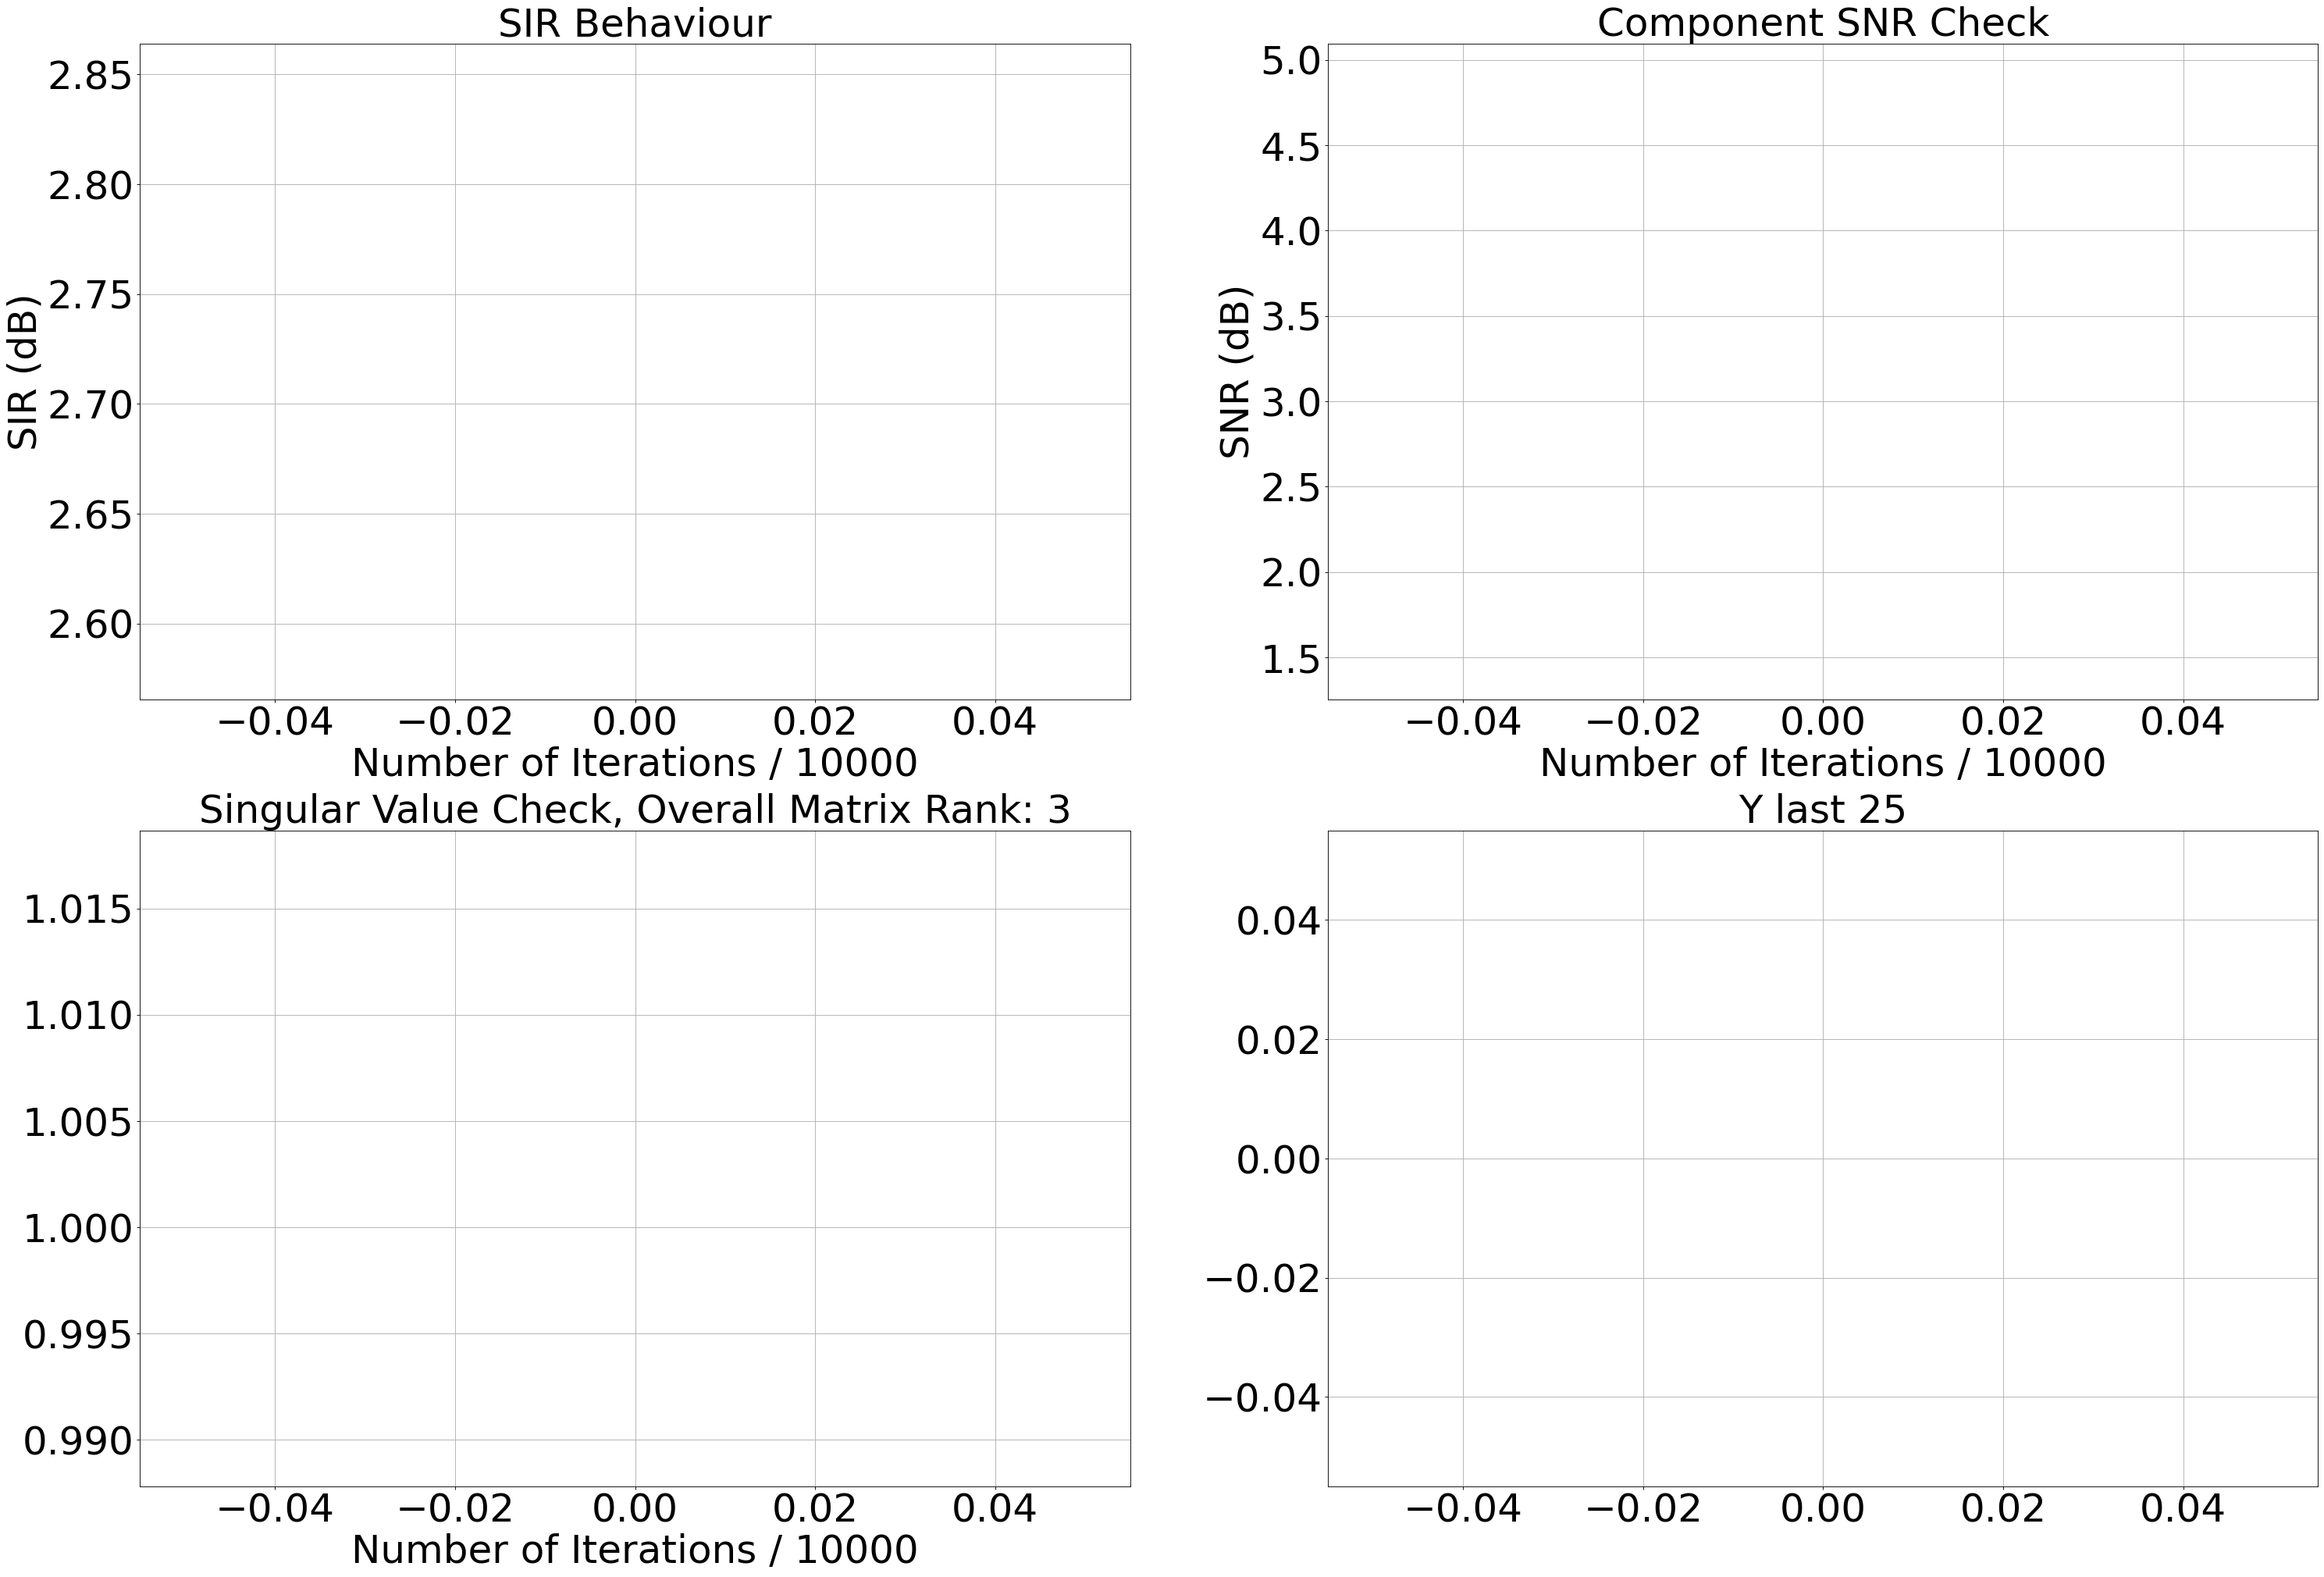

 12%|█▏        | 10000/80020 [00:07<00:54, 1284.51it/s]


LinAlgError: SVD did not converge

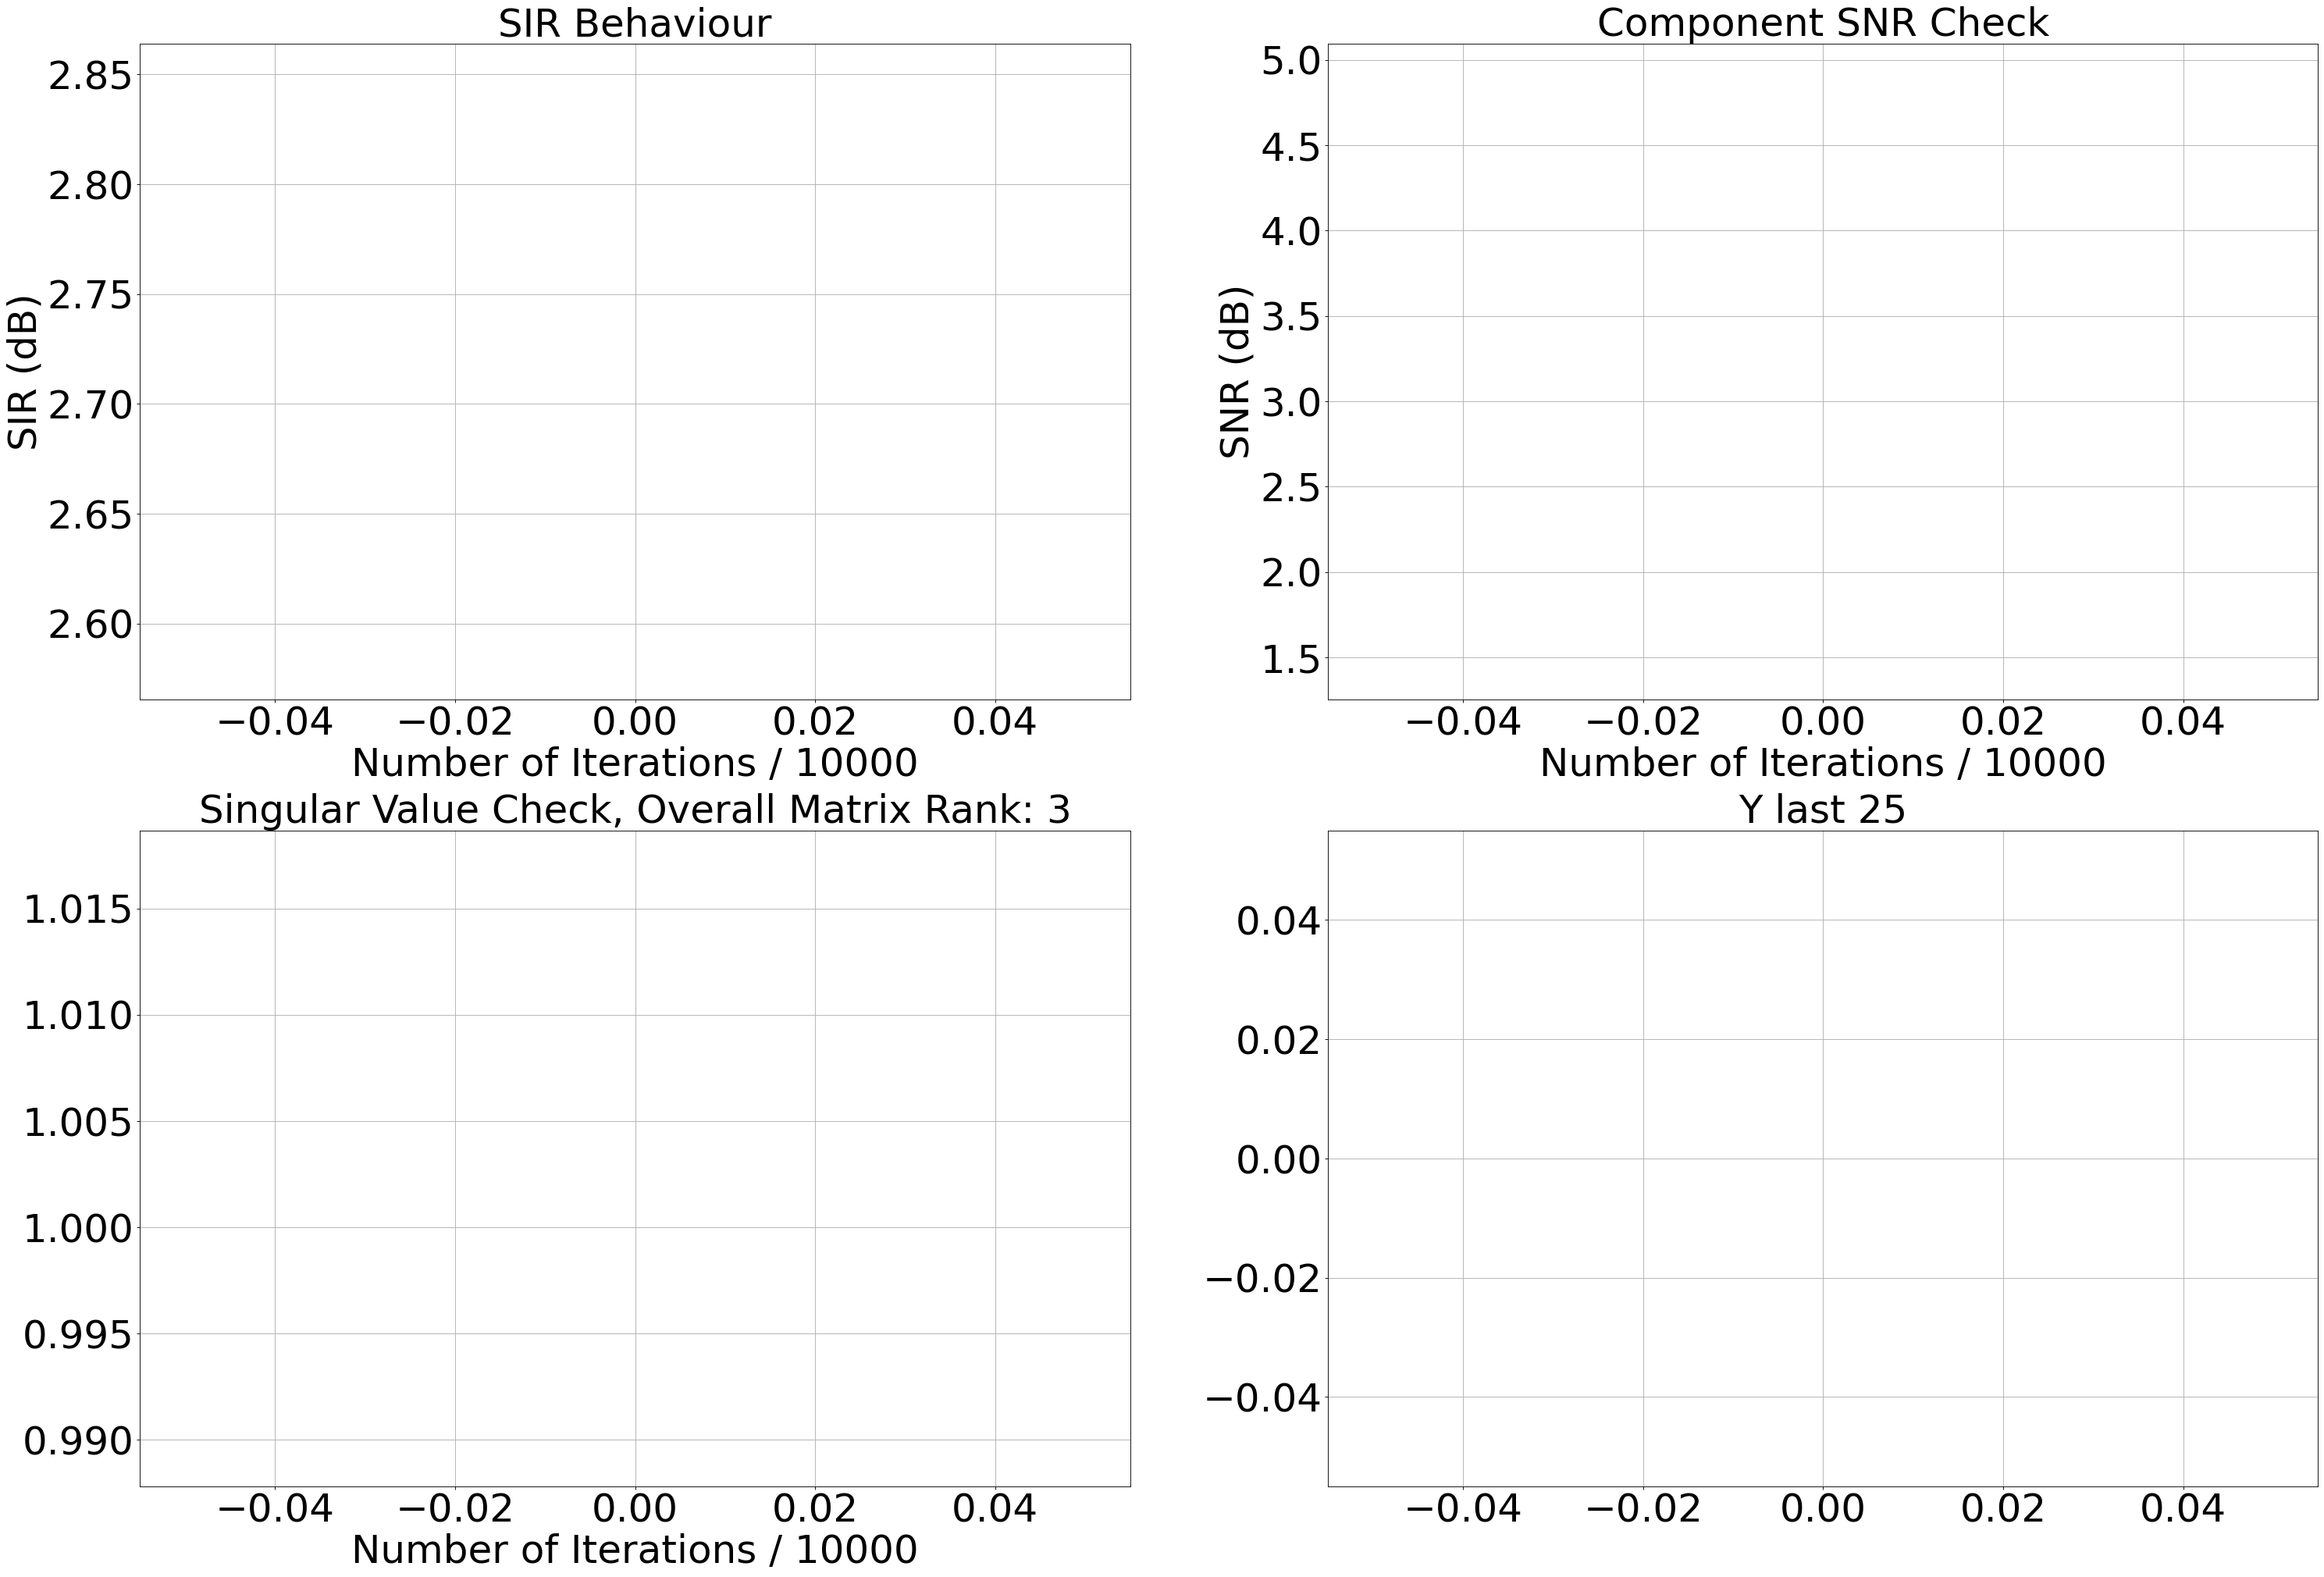

In [7]:
hyperparam_dict = {
                "n_sources" :  NumberofSources,
                "presumed_domain" : "sparse",
                ### Optimization parameters
                "lambda_lateral" : 0.99,
                "gamma_predictive" : 5,
                ### Learning rates 
                "lr_W" : 1 * 1e-2,
                "neural_lr_start" : 0.01,
                "neural_lr_stop" : 1e-4,
                "stlambda_lr" : 0.01,
                "neural_dynamics_iterations" : 250,
                "neural_OUTPUT_COMP_TOL" : 1e-7,
                ### Learning rate rules and decay parameters
                "lr_W_rule" : "constant",
                "lr_W_decay_divider" : 5000,
                "neural_lr_rule" : "divide_by_loop_index",
                "neural_lr_decay_divider" : 0.01,
                ### Initial values for weights if provided, if not they will be initialized in the fit function 
                "W" : None,
                "B_y" : None,
                ### Ground truth source vectors. This part is only for debugging.
                "Sgt" : S_wavelet,
                "debug_iteration_point" : 10000,
                "plot_debug_during_training" : True,
}
model = OnlineCorInfomax(**hyperparam_dict)
model.fit(X_wavelet, shuffle_samples = True)

In [ ]:
display_matrix(model.B_y)

In [ ]:
display_matrix(model.W)

In [ ]:
Y_ = model.predict(X)
Y_ = model.signed_and_permutation_corrected_sources(S, Y_) # Find sign and permutation ambiguity
coef_ = ((Y_ * S).sum(axis=1) / (Y_ * Y_).sum(axis=1)).reshape(-1, 1) # Find if the extracted signals need some amplification! The networks learned weight may need amplification due to lateral connections during the neural dynamics!
Y_ = coef_ * Y_

print("Signal-to-Interference-and-Noise-Ratio (SINR): {}".format(model.ComputeSINR(Y_, S)))
print("Component Signal-to-Noise-Ratio (SNR) Values : {}\n".format(model.ComputeSNR(S, Y_)))

In [ ]:
plot_bss_comparison(S[:, 500:1600], Y_[:, 500:1600])